# Imports, object creating, read csv
- Import required modules
- Create HealthAnalyzer object
- Load csv data

In [1]:
from src.HealthAnalyzer import HealthAnalyzer
from src.viz import plot_histogram, plot_boxplot, plot_barplot, lin_regress
from src.metrics import sample_mean, normal_ci95, bootstrap_ci95
import numpy as np
np.random.seed(42)

ha = HealthAnalyzer()
ha.read_csv(".\\data\\health_study_dataset.csv")
print(ha.data().head())

File '.\data\health_study_dataset.csv' read successfully!
   id  age sex  height  weight  systolic_bp  cholesterol smoker  disease
0   1   57   F   168.9    65.8        141.8         4.58     No        0
1   2   47   M   180.4    95.9        144.8         5.18    Yes        0
2   3   59   F   169.9    82.2        151.7         6.16     No        0
3   4   72   M   157.7    93.1        151.0         6.63     No        0
4   5   46   M   192.6   104.1        144.1         5.21     No        0


# Part 1
### Descriptive Analysis
- Shows the mean, median, min, max and std of age, weight, height, systolic_bp and cholesterol

In [2]:
display(ha.desc_analysis())

,Mean,Median,Min,Max,Std
age,49.426250,50.00,18.0,90.00,14.501118
weight,73.413000,73.20,33.7,114.40,13.685059
height,171.849250,171.35,144.4,200.40,9.804259
systolic_bp,149.178625,149.40,106.8,185.90,12.793360
cholesterol,4.929150,4.97,2.5,7.88,0.848413


### Graphs
- Histogram of systolic bp

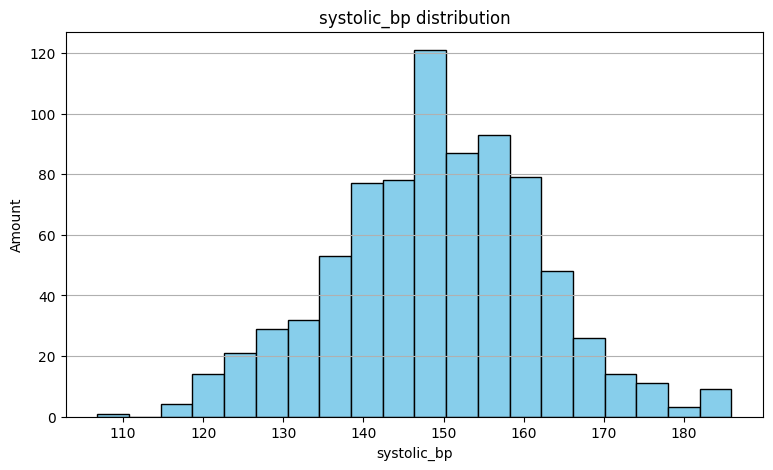

In [3]:
plot_histogram(ha.data(), "systolic_bp", 20)

- Boxplot of weight per sex

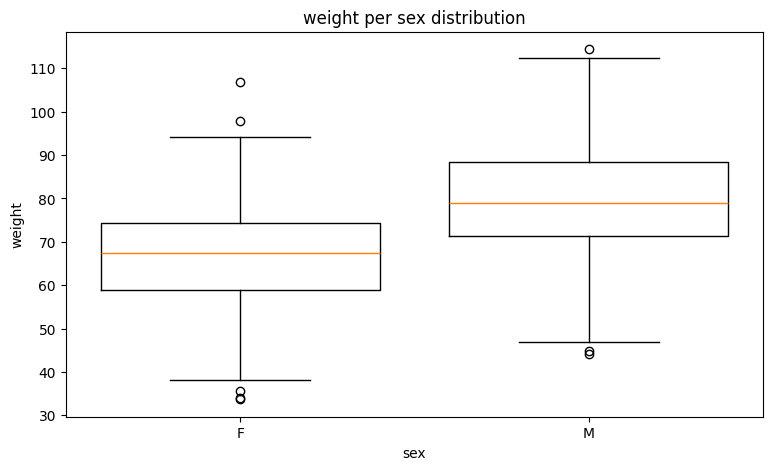

In [4]:
plot_boxplot(ha.data(), "sex", ["F", "M"], "weight")

- Barplot over smokers and non-smokers

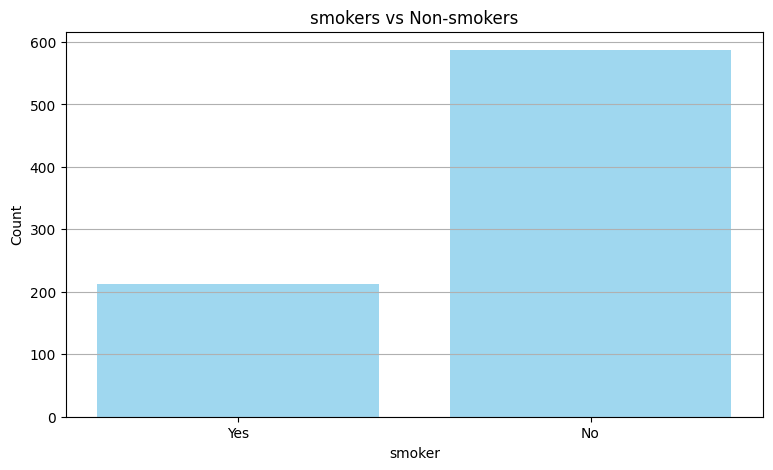

In [5]:
plot_barplot(ha.data(), "smoker", ["Yes", "No"])

# Simulation connected to the case

### We calculate the actual sick rate and compares it with the sick rate of 1000 simulated people
- Actual rate of sickness

In [6]:
actual_sick_rate = ha.sick_rate(ha.data())

print(f"The actual rate of sickness is: {actual_sick_rate * 100.0:.3f}%")

The actual rate of sickness is: 5.875%


- Simulate 1000 people with the same sickness-rate

In [7]:
sim_data = ha.simulate_data(1000)
sim_sick_rate = ha.sick_rate(sim_data)

print(f"The simulated sick rate is: {sim_sick_rate * 100.0:.3f}%")

print(f"The difference between the actual sick rate and simulated sick rate is roughly: {abs((sim_sick_rate - actual_sick_rate) * 100):.3f} percentage units.")

The simulated sick rate is: 5.000%
The difference between the actual sick rate and simulated sick rate is roughly: 0.875 percentage units.


# Confidence Intervals
### We calculate the confidence interval of the systolic_bp using normal approximation and bootstrap
- Normal Approximation of systolic_bp

In [8]:
lo_n, hi_n, mean_n, std_n = normal_ci95(ha.data()["systolic_bp"])
print("Normal Approximation Confidence Interval 95% for systolic_bp")
print(f"Low: {lo_n}\nHi: {hi_n}\nMean: {mean_n}\nStd: {std_n}")

Normal Approximation Confidence Interval 95% for systolic_bp
Low: 148.29209036025347
Hi: 150.06515963974655
Mean: 149.178625
Std: 12.793360316766597


- Bootstrap of systolic_bp

In [9]:
lo_b, hi_b, mean_b, std_b = bootstrap_ci95(ha.data()["systolic_bp"])
print("Bootstrap Confidence Interval 95% for systolic_bp")
print(f"Low: {lo_b}\nHi: {hi_b}\nMean: {mean_b}\nStd: {std_b}")

Bootstrap Confidence Interval 95% for systolic_bp
Low: 148.3081125
Hi: 150.07639375
Mean: 149.178625
Std: 12.785361966302519


# Hypothesis Test
- A two-sample t-test hypothesis test will be used.
## **Step 1:** Check assumptions
- True. Independant measurements. The observations from the smoker group does not affect the observations from the non-smoker group.
- True. The collected data is a random sample from the population. A random sample of 800 people were used from the worlds population of people. (I assume the data is a random sample from Joakim :) since I have no idea where the data originally came from.)
- True. The data seems to be normally distributed. Check graphs below.
- True. The data is continuous as blood pressure is considered a continuous value. It would not jump from 140 to 141 in a single step. It must rise continuously from 140 to 141. (We assume it is continuous as we don't know the universe's limit and in practice it is very much continuous)
- True. We assume similar variance.
## **Step 2:** Determine h0 and h1
- The claim is "Smokers have higher mean bp than non smokers" and since it contains no form of equality, it must be the alternative hypothesis. This gives us a right-tailed test.
- The null hypothesis must therefore be the opposite. "Smokers have lower or equal mean bp than non smokers"
- We must reject the null hypothesis to be able to accept the alternative hypothesis.
- If we fail to reject the null hypothesis then no conclusion can be drawn.
## **Step 3:** Define groups and calculate t and p-values
- Make two groups. In this case smokers and non-smokers along with they systolic_bp.
- Use SciPy to calculate the t and p-values
- Compare to our alpha (1.0 - conf). Alpha is 0.05 in this case. 

In [10]:
from src.metrics import standard_t_test

conf = 0.95
alpha = 1.0 - conf

smokers = ha.data().loc[ha.data().smoker == "Yes", "systolic_bp"].values
non_smokers = ha.data().loc[ha.data().smoker == "No", "systolic_bp"].values

t_stat, p_val = standard_t_test(smokers, non_smokers, "greater")
print(f"t-stat:  {t_stat}\np-value: {p_val}\nAlpha:   {alpha}")

if p_val < alpha:
	print("Since {p_val:.3f} < {alpha:.3f}, the null hypothesis is rejected. The alternative hypothesis has enough\n" \
	"evidence to be supported.")
else:
	print(f"Since p={p_val:.3f} > alpha={alpha:.3f}, you failed to reject the null hypothesis! There is not enough evidence\n" \
	"to say that smokers have higher mean bp than non-smokers.")

t-stat:  0.4609102005307389
p-value: 0.3224943095483599
Alpha:   0.050000000000000044
Since p=0.322 > alpha=0.050, you failed to reject the null hypothesis! There is not enough evidence
to say that smokers have higher mean bp than non-smokers.


# two-sample t-test Conclusion
- Since the p-value is greater than the alpha (0.05) for a confidence of 95% in a right-tailed test, the null hypothesis fails to be rejected. Therefore, the alternative hypothesis does not have enough evidence to be supported.
- Not enough evidence to say that smokers have higher mean bp than non-smokers.

# Linear regression
- Systolic bp over age

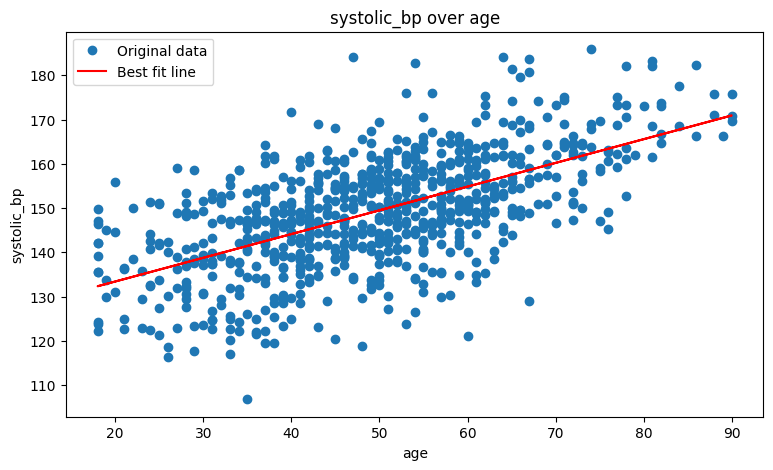

In [11]:
lin_regress(ha.data(), ["age", "systolic_bp"])

- Systolic bp over weight

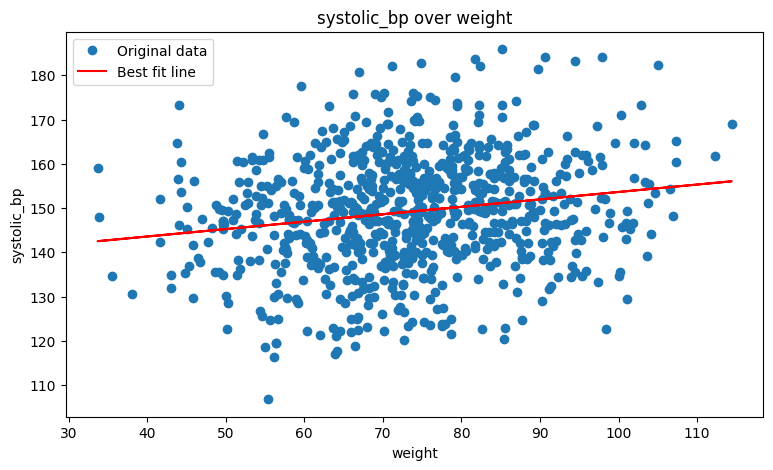

In [12]:
lin_regress(ha.data(), ["weight", "systolic_bp"])

# Linear Regression Conclusion
- It appears that the systolic bp increases with both age and weight.
- Age seems to be a bigger cause of high systolic bp than weight.